In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, chi2_contingency

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

df.head()

,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11 00:00:00,2024-07-11,212,482.0,13,9,19.84,459.32,126,47,7.0,45555.63,82.64,Normal
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24 00:00:00,2025-03-19,357,640.0,8,6,34.81,1072.54,110,75,5.0,36577.48,94.58,Normal
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01 00:00:00,2023-03-06,104,538.0,5,3,49.66,1891.81,118,66,12.0,23742.67,98.22,Overstock
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13 00:00:00,2024-06-04,161,530.0,9,2,20.00,662.42,119,11,8.0,49287.57,97.45,Low Stock
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01 00:00:00,2023-05-09,289,397.0,14,3,32.63,1115.41,128,42,3.0,16929.86,86.75,Overstock


In [3]:
df["Inventory_Risk"] = np.where(
    df["Inventory_Status"].isin(["Critical", "Low Stock"]),
    "High Risk",
    "Low Risk"
)

In [4]:
high_risk = df[df["Inventory_Risk"] == "High Risk"]["Avg_Daily_Sales"]
low_risk = df[df["Inventory_Risk"] == "Low Risk"]["Avg_Daily_Sales"]

t_stat, p_value = ttest_ind(high_risk, low_risk)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.095173515113798
P-value: 0.27348000485119245


In [5]:
groups = []

for category in df["Category"].unique():
    groups.append(
        df[df["Category"] == category]["Stock_Age_Days"]
    )

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.6074561410589585
P-value: 0.12820434054077723


In [6]:
contingency = pd.crosstab(
    df["ABC_Class"],
    df["Inventory_Status"]
)

contingency

Inventory_Status,Critical,Low Stock,Normal,Overstock
ABC_Class,,,,
A,563,563,606,558
B,547,540,586,564
C,550,545,566,512


In [7]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-Square:", chi2)
print("P-value:", p_value)

Chi-Square: 2.0836442991460222
P-value: 0.9118472496945949


In [8]:
df["Days_Of_Inventory"] = (
    df["Quantity_On_Hand"] /
    df["Avg_Daily_Sales"]
)

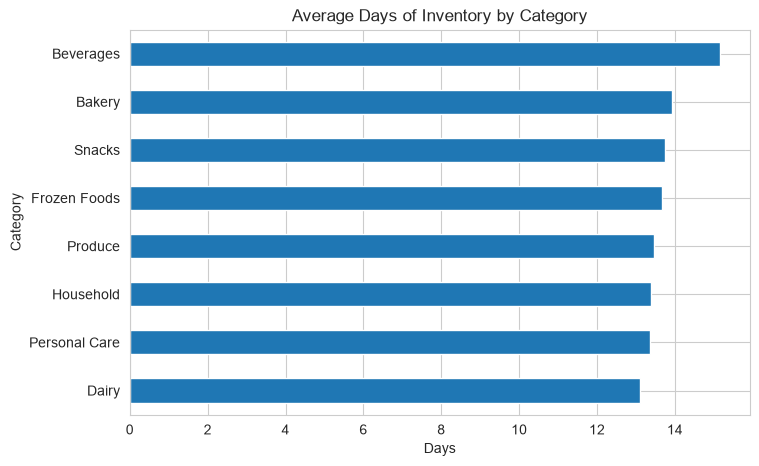

In [9]:
plt.figure(figsize=(8,5))

df.groupby("Category")["Days_Of_Inventory"]\
  .mean()\
  .sort_values()\
  .plot(kind="barh")

plt.title("Average Days of Inventory by Category")
plt.xlabel("Days")
plt.show()

In [10]:
df["Purchase_Year"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.year
)

df["Purchase_Month"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.month_name()
)

df["Purchase_Day"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.day
)

In [11]:
df["Purchase_Month"].value_counts()

Purchase_Month
May          724
April        676
June         640
March        636
July         582
January      544
February     531
August       499
December     494
November     472
October      452
September    450
Name: count, dtype: int64

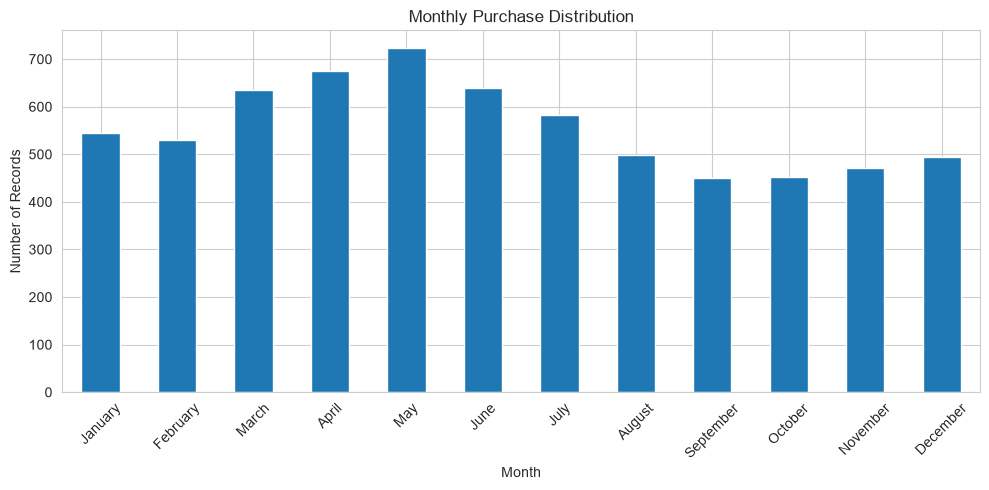

In [12]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_counts = (
    df["Purchase_Month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(10,5))
monthly_counts.plot(kind="bar")

plt.title("Monthly Purchase Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_purchase_distribution.png")
plt.show()

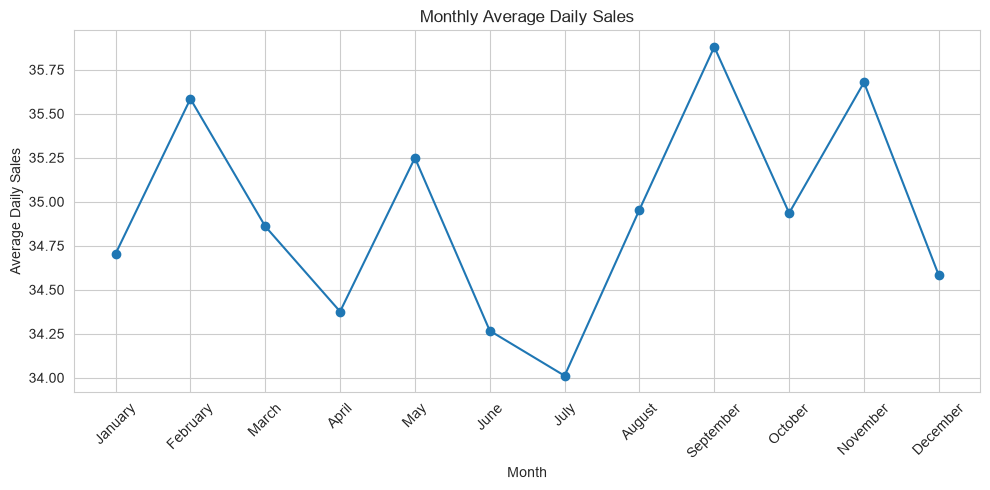

In [13]:
monthly_sales = (
    df.groupby("Purchase_Month")["Avg_Daily_Sales"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Average Daily Sales")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_avg_sales.png")
plt.show()

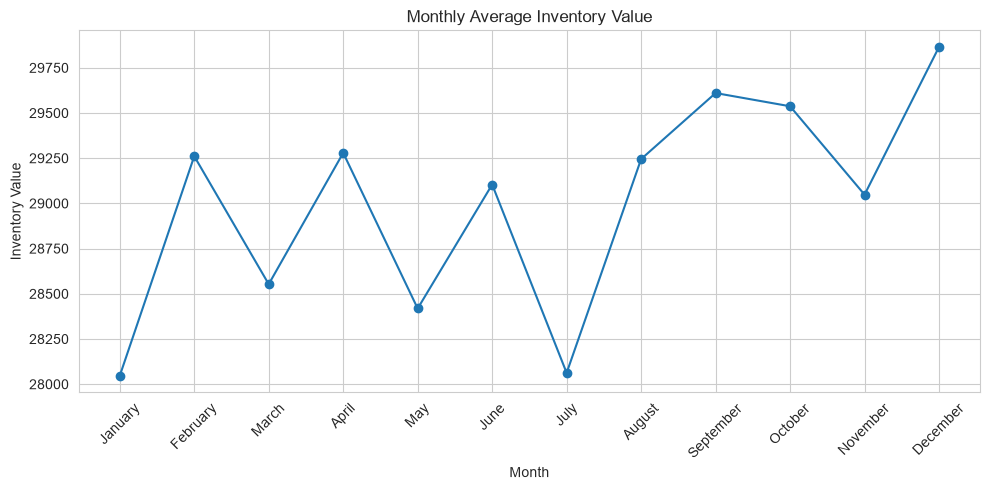

In [14]:
monthly_value = (
    df.groupby("Purchase_Month")["Total_Inventory_Value_USD"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_value.index,
         monthly_value.values,
         marker="o")

plt.title("Monthly Average Inventory Value")
plt.xlabel("Month")
plt.ylabel("Inventory Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_inventory_value.png")
plt.show()

In [15]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/final_cleaned_day4.csv",
    index=False
)

### Key Findings

- A T-test was performed to compare average daily sales between high-risk and low-risk inventory groups. The results indicated no statistically significant difference between the two groups.
- An ANOVA test was conducted to determine whether stock age differed across product categories. The results suggested that the observed differences were not statistically significant.
- A Chi-Square test was used to examine the relationship between ABC classification and inventory status. The analysis indicated no significant association between these variables.
- A new feature, **Days_Of_Inventory**, was created to estimate how long current inventory can support demand based on average daily sales. Category-level analysis showed differences in inventory coverage across product groups.
- Time-based features such as **Purchase Year** and **Purchase Month** were extracted from purchase dates to support temporal analysis.
- Monthly purchase distribution revealed that purchasing activity was spread throughout the year, with some variation in record counts across months.
- Average daily sales and inventory value remained relatively stable across months, suggesting the absence of strong seasonal patterns within the dataset.

### Overall Conclusion

The analysis showed that inventory performance remained generally stable across categories, risk groups, and time periods. While some variations were observed, statistical testing did not provide evidence of strong relationships among the tested variables. Feature engineering and time-based analysis improved the understanding of inventory coverage, purchasing behavior, and overall inventory management patterns.